
# <span style="color:rgb(213,80,0)">Tutorial 5 \- Simulate CC\-CV Cycling</span>

## Introduction

In this tutorial, we will use a P2D model to simulate CC\-CV cycling. After completing this tutorial, you should have a working knowledge of:

-  How to define and modify cycling protocols in BattMo

We'll use the same model from Tutorial 1.


In [1]:
jsonstruct = parseBattmoJson('Examples/jsondatafiles/sample_input.json');


Parameters are defined in the JSON parameter file and parsed into the MATLAB structure. Once the JSON file has been read into MATLAB as a jsonstruct, its properties can be modified programmatically.

## Explore the Control Definition

Let's begin by reviewing the control protocol in BattMo, with the command:


In [2]:
disp(jsonstruct.Control)

         controlPolicy: 'CCDischarge'
                 DRate: 1
    lowerCutoffVoltage: 3
    upperCutoffVoltage: 4.100000000000000
             dIdtLimit: 0.010000000000000
             dEdtLimit: 0.010000000000000
            rampupTime: 0.100000000000000



We see that the default control protocol is set to a constant current (galvanostatic) discharge. To change to a CC\-CV cycling protocol, we can use the command:


In [3]:
cccv_control_protocol = parseBattmoJson('cccv_control.json');
jsonstruct_modified = mergeStructs({cccv_control_protocol, jsonstruct});

mergeStructs: Parameter Control.controlPolicy is assigned twice with different values. Value from first jsonstruct is used.
mergeStructs: Parameter Control.lowerCutoffVoltage is assigned twice with different values 2.8 and 3, relative difference is 0.0344828. Value from first jsonstruct is used.
mergeStructs: Parameter Control.upperCutoffVoltage is assigned twice with different values 4.2 and 4.1, relative difference is 0.0120482. Value from first jsonstruct is used.
mergeStructs: Parameter Control.dIdtLimit is assigned twice with different values 2e-06 and 0.01, relative difference is 0.9996. Value from first jsonstruct is used.
mergeStructs: Parameter Control.dEdtLimit is assigned twice with different values 2e-06 and 0.01, relative difference is 0.9996. Value from first jsonstruct is used.



Now we can explore the modified control protocol definition with the command:


In [4]:
disp(jsonstruct_modified.Control)

         controlPolicy: 'CCCV'
        initialControl: 'discharging'
        numberOfCycles: 5
                 CRate: 0.500000000000000
                 DRate: 1
    lowerCutoffVoltage: 2.800000000000000
    upperCutoffVoltage: 4.200000000000000
             dIdtLimit: 2.000000000000000e-06
             dEdtLimit: 2.000000000000000e-06
            rampupTime: 0.100000000000000



Let's run the simulation and plot the cell voltage curve.


In [5]:
% run the simulation
output = runBattery(jsonstruct_modified);



get the states



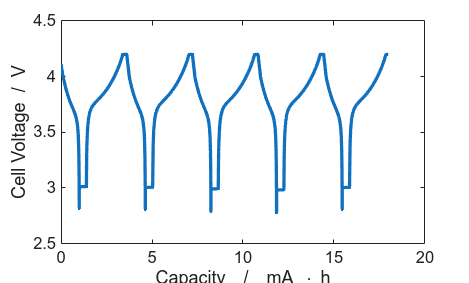

In [6]:
states = output.states;

% extract the time and voltage quantities
time = cellfun(@(state) state.time, states);
voltage = cellfun(@(state) state.('Control').E, states);
current = cellfun(@(state) state.('Control').I, states);

% calculate the capacity
capacity = time .* current;

% plot the discharge curve in the figure
plot(time/hour, voltage, '-', 'linewidth', 3)

% add plot annotations
xlabel('Capacity  /  mA \cdot h')
ylabel('Cell Voltage  /  V')

## Summary

In this tutorial, we explored how to modify material parameters in BattMo.


In [7]:
%{
Copyright 2021-2026 SINTEF Industry, Sustainable Energy Technology
and SINTEF Digital, Mathematics & Cybernetics.

This file is part of The Battery Modeling Toolbox BattMo

BattMo is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

BattMo is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with BattMo.  If not, see <http://www.gnu.org/licenses/>.
%}